## split data

In [1]:
from Bio import SeqIO

fasta_file = "../data/raw_data/Homo_sapiens.GRCh38.107.utrs"
utr5_file = "../data/5utr_homo.fasta"
utr3_file = "../data/3utr_homo.fasta"

records = SeqIO.parse(fasta_file, "fasta")

with open(utr5_file, "w") as f5, open(utr3_file, "w") as f3:
    utr5_count = 0
    utr3_count = 0
    for record in records:
        parts = record.id.split("|")
        utr_type = parts[1]  # five_prime_utr 或 three_prime_utr
        transcript_id = parts[2]
        gene_name = parts[3]
        location = parts[4]

        sequence = str(record.seq)

        fasta_record = f">{transcript_id}|{gene_name}|{location}\n{sequence}\n"

        if utr_type == "five_prime_utr":
            utr5_count += 1
            f5.write(fasta_record)
        elif utr_type == "three_prime_utr":
            utr3_count += 1
            f3.write(fasta_record)

# Print summary of processed UTR sequences

print(f"5'UTR: {utr5_count} seqs -> {utr5_file}")
print(f"3'UTR: {utr3_count} seqs -> {utr3_file}")
print(f"Total: {utr5_count + utr3_count} seqs")
print("Done!")
        
    

5'UTR: 171504 seqs -> ../data/5utr_homo.fasta
3'UTR: 203201 seqs -> ../data/3utr_homo.fasta
Total: 374705 seqs
Done!


## plot length distribution

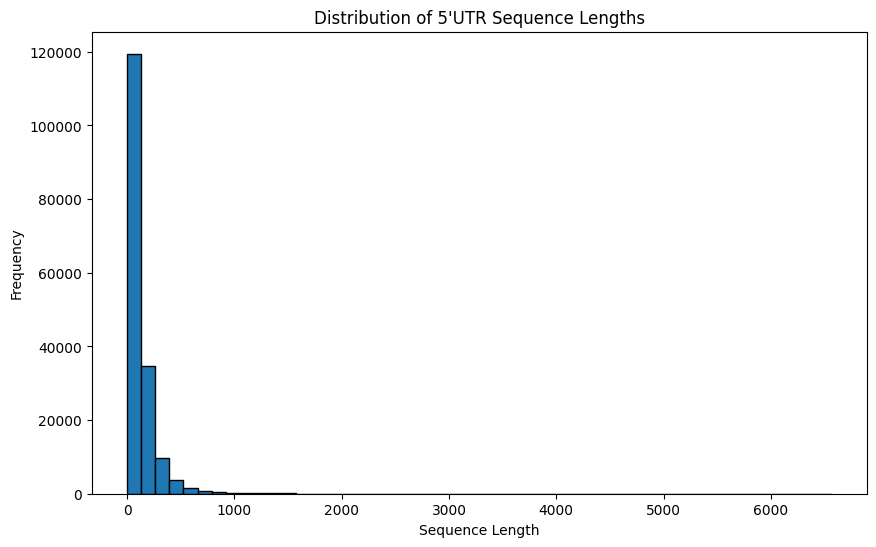

Total number of 5'UTR sequences: 171504
Shortest sequence length: 1
Longest sequence length: 6566
Average sequence length: 126.41


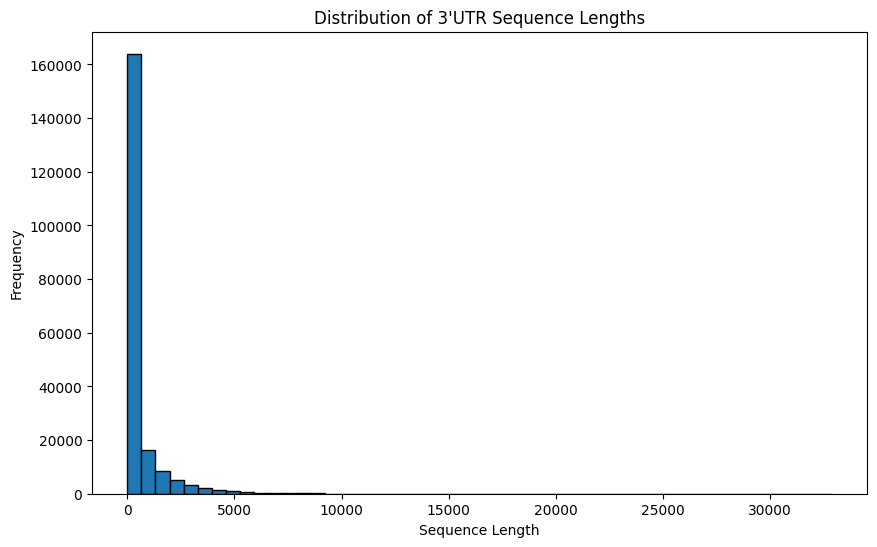

Total number of 3'UTR sequences: 203201
Shortest sequence length: 1
Longest sequence length: 32870
Average sequence length: 537.16


In [2]:
from Bio import SeqIO
import matplotlib.pyplot as plt
%matplotlib inline

utr5_file = "../data/5utr_homo.fasta"
utr3_file = "../data/3utr_homo.fasta"

lengths = []
with open(utr5_file, "r") as f:
    for record in SeqIO.parse(f, "fasta"):
        lengths.append(len(record.seq))

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, edgecolor='black')
plt.title("Distribution of 5'UTR Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

print(f"Total number of 5'UTR sequences: {len(lengths)}")
print(f"Shortest sequence length: {min(lengths)}")
print(f"Longest sequence length: {max(lengths)}")
print(f"Average sequence length: {sum(lengths)/len(lengths):.2f}")

lengths = []
with open(utr3_file, "r") as f:
    for record in SeqIO.parse(f, "fasta"):
        lengths.append(len(record.seq))

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, edgecolor='black')
plt.title("Distribution of 3'UTR Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

print(f"Total number of 3'UTR sequences: {len(lengths)}")
print(f"Shortest sequence length: {min(lengths)}")
print(f"Longest sequence length: {max(lengths)}")
print(f"Average sequence length: {sum(lengths)/len(lengths):.2f}")

## combine 5utr from ncbi and ensembl (without homo sapiens)

In [4]:
import tempfile
import os
# ncbi
ncbi_file = "../data/raw_data/5utr_ncbi.fasta"
sequences = list(SeqIO.parse(ncbi_file, "fasta"))

filtered_sequences = [record for record in sequences if not any(keyword in record.description for keyword in ["SYN", "PAT", "ENV", "HTC"])]

with tempfile.NamedTemporaryFile(mode='w', delete=False) as temp_file:
    for record in filtered_sequences:
        # 直接使用原始的头部信息
        header = f">{record.description}\n"
        # 将序列转换为字符串，并确保只占一行
        sequence = str(record.seq) + "\n"
        temp_file.write(header)
        temp_file.write(sequence)
os.replace(temp_file.name, ncbi_file)

# ensembl
ensembl_files = {
    "../data/raw_data/ensembl_5species/Fivespecies_chicken_energy_structure_31577sequence.fasta": "VRT",
    "../data/raw_data/ensembl_5species/Fivespecies_mouse_energy_structure_48378sequence.fasta": "ROD",
    "../data/raw_data/ensembl_5species/Fivespecies_rat_energy_structure_27740sequence.fasta": "ROD",
    "../data/raw_data/ensembl_5species/Fivespecies_zebrafish_energy_structure_28819sequence.fasta": "VRT"
}
output_file = "../data/raw_data/5utr_ensembl.fasta"
with open(output_file, "w") as output_handle:
    for input_file, species in ensembl_files.items():
        # 读取每个FASTA文件中的序列
        sequences = SeqIO.parse(input_file, "fasta")
        for record in sequences:
            seq_length = len(record.seq)
            new_description = f"> {seq_length} {species}\n"
            output_handle.write(new_description)
            output_handle.write(str(record.seq) + "\n")

# combine ncbi and ensembl
file1 = "../data/raw_data/5utr_ncbi.fasta"
file2 = "../data/raw_data/5utr_ensembl.fasta"
output_file = "../data/5utr_noHomo.fasta"

count = 0
with open(output_file, "w") as output_handle:
    # ncbi
    for record in SeqIO.parse(file1, "fasta"):
        count += 1
        header = f">{record.description}\n"
        sequence = str(record.seq) + "\n"
        output_handle.write(header)
        output_handle.write(sequence)
    
    # 处理Ensembl文件
    for record in SeqIO.parse(file2, "fasta"):
        count += 1
        header = f">{record.description}\n"
        sequence = str(record.seq) + "\n"
        output_handle.write(header)
        output_handle.write(sequence)
    
print(f"组合完成。结果保存在 {output_file}")
print(f"组合后的总序列数: {count}")

组合完成。结果保存在 ../data/5utr_noHomo.fasta
组合后的总序列数: 172329
